In [17]:
# Set parameters
param_intermediary_results_location <- "/home/jovyan/Cloud Storage/naa-vre-user-data/tmp/data/"

In [14]:
#load necessary packages

if (!require("pacman")) install.packages("pacman")
pacman::p_load("dplyr", "terra", "sf")


In [15]:
# Load and transform the Natura2000 Veluwe geopackage
natura2000_sf <- sf::read_sf("https://service.pdok.nl/rvo/natura2000/atom/downloads/natura2000.gpkg") %>%
sf::st_transform(28992)

# Create the veluwe sf by filtering the Natura2000 shapefile 
veluwe_sf <- natura2000_sf %>%
  dplyr::filter(objectid == 4049)

# Save the as geopackage to tmp data so that it can be used in later cells 
veluwe_sf_datafile <- "/home/jovyan/Cloud Storage/naa-vre-user-data/tmp/data/veluwe_sf.gpkg"
sf::st_write(veluwe_sf, veluwe_sf_datafile, append = FALSE)

Deleting layer `veluwe_sf' using driver `GPKG'
Writing layer `veluwe_sf' to data source 
  `/home/jovyan/Cloud Storage/naa-vre-user-data/tmp/data/veluwe_sf.gpkg' using driver `GPKG'
Writing 1 features with 14 fields and geometry type Multi Polygon.


In [ ]:
#download and unzip in pH data
pH_url <- "https://data.4tu.nl/file/0c934ac6-2e95-4422-8360-d3a802766c71/447dd6ba-4a5f-4006-9c68-f3c3b4452206"

pH_zip <- "/home/jovyan/Cloud Storage/naa-vre-user-data/tmp/data/4tu_download.zip"
out_dir <- "/home/jovyan/Cloud Storage/naa-vre-user-data/tmp/data/4tu_download"

download.file(pH_url, pH_zip, mode = "wb", method = "libcurl")

options(timeout=60*60)
unzip(pH_zip, exdir = out_dir)


In [16]:
#select pH layer
pH <- rast("/home/jovyan/Cloud Storage/naa-vre-user-data/tmp/data/4tu_download/pH/pH_KCl_d_5_15_QRF_pred_mean.tif")
veluwe_v <- terra::vect(veluwe_sf_datafile)

pH_veluwe <- terra::crop(pH, veluwe_v)
pH_veluwe <- terra::mask(pH_veluwe, veluwe_v)

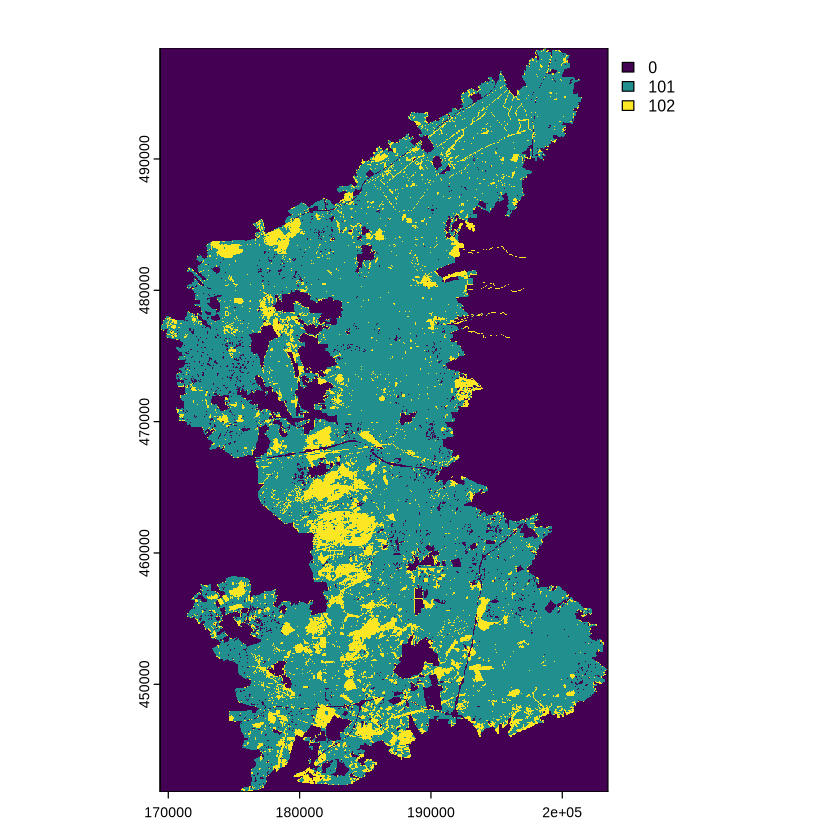

In [6]:
#102 ecoregion for pH>4; 101 ecoregion for ph < 4, empty cells are set to 0
pH_ecoregions <- terra::ifel(pH_veluwe> 4, 102, 101)
pH_ecoregions <- terra::ifel(is.na(pH_ecoregions), 0, pH_ecoregions)
plot(pH_ecoregions)


In [18]:
#save as tif file
ecoregions_tif <- paste0(param_intermediary_results_location, "ecoregions.tif")

terra::writeRaster(pH_ecoregions, 
            filename = ecoregions_tif, 
            datatype = "INT1U",
            overwrite = TRUE)